In [171]:
# Interpretable Machine Learning for 30-Day Diabetes Hospital Readmission Prediction

#Dataset:** UCI Diabetes 130-US Hospitals for Years 1999–2008  
#Goal:** Predict whether a diabetic inpatient encounter results in readmission within 30 days.


#This project compares multiple machine learning models, evaluates performance using healthcare-relevant metrics, analyzes model interpretability, and checks fairness across demographic groups.

In [172]:
INSTALL_PACKAGES = True

if INSTALL_PACKAGES:
    import sys
    import subprocess

    packages = [
        "ucimlrepo",
        "scikit-learn",
        "pandas",
        "numpy",
        "matplotlib",
        "seaborn",
        "joblib"
    ]

    for pkg in packages:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

    optional_packages = ["xgboost", "shap"]

    for pkg in optional_packages:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        except Exception as e:
            print(f"Optional package {pkg} could not be installed: {e}")

In [173]:
import os
import warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, GroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports complete.")

Imports complete.


In [174]:
FAST_MODE = False
RUN_TUNING = False
RUN_OPTIONAL_XGBOOST = True
RUN_OPTIONAL_SHAP = False

print("FAST_MODE:", FAST_MODE)
print("RUN_TUNING:", RUN_TUNING)
print("RUN_OPTIONAL_XGBOOST:", RUN_OPTIONAL_XGBOOST)
print("RUN_OPTIONAL_SHAP:", RUN_OPTIONAL_SHAP)

FAST_MODE: False
RUN_TUNING: False
RUN_OPTIONAL_XGBOOST: True
RUN_OPTIONAL_SHAP: False


In [175]:
LOCAL_CSV_PATH = "diabetic_data.csv"

def load_diabetes_data():
    try:
        from ucimlrepo import fetch_ucirepo

        dataset = fetch_ucirepo(id=296)

        X = dataset.data.features.copy()
        y = dataset.data.targets.copy()

        # Add ID columns if ucimlrepo stores them separately
        if hasattr(dataset.data, "ids") and dataset.data.ids is not None:
            ids = dataset.data.ids.copy()
            X = pd.concat([ids, X], axis=1)

        if isinstance(y, pd.DataFrame):
            y_col = y.columns[0]
            y = y[y_col]

        df = X.copy()
        df["readmitted"] = y.values

        print("Loaded dataset from ucimlrepo.")
        return df

    except Exception as e:
        print("Could not load from ucimlrepo.")
        print("Error:", e)

        if Path(LOCAL_CSV_PATH).exists():
            print(f"Loading local file: {LOCAL_CSV_PATH}")
            return pd.read_csv(LOCAL_CSV_PATH)

        raise FileNotFoundError(
            "Dataset not found. Place diabetic_data.csv in the notebook folder "
            "or enable internet access for ucimlrepo."
        )

In [176]:
df_raw = load_diabetes_data()

print("Dataset shape:", df_raw.shape)
df_raw.head()

Loaded dataset from ucimlrepo.
Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [177]:
df = df_raw.copy()

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.value_counts())

Shape: (101766, 50)

Columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data types:


object    37
int64     13
Name: count, dtype: int64

In [178]:
print("Readmission outcome counts:")
display(df["readmitted"].value_counts(dropna=False))

print("Readmission outcome proportions:")
display(df["readmitted"].value_counts(normalize=True, dropna=False).round(4))

Readmission outcome counts:


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Readmission outcome proportions:


readmitted
NO     0.5391
>30    0.3493
<30    0.1116
Name: proportion, dtype: float64

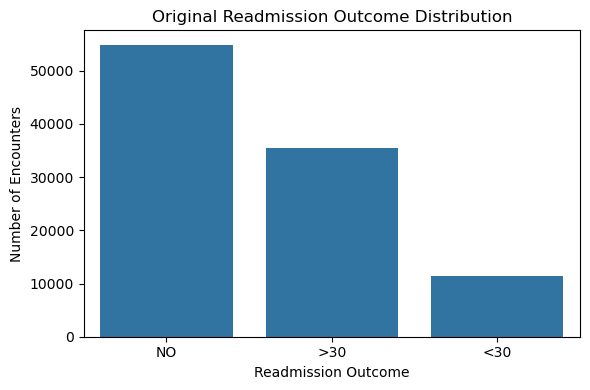

In [179]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="readmitted", order=["NO", ">30", "<30"])
plt.title("Original Readmission Outcome Distribution")
plt.xlabel("Readmission Outcome")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.show()

In [180]:
df_missing = df.replace("?", np.nan)

missing_rate = df_missing.isna().mean().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_rate": missing_rate,
    "missing_count": df_missing.isna().sum()
})

display(missing_summary.head(25))

,missing_rate,missing_count
A1Cresult,0.832773,84748
acarbose,0.000000,0
acetohexamide,0.000000,0
admission_source_id,0.000000,0
admission_type_id,0.000000,0
age,0.000000,0
change,0.000000,0
chlorpropamide,0.000000,0
citoglipton,0.000000,0
diabetesMed,0.000000,0


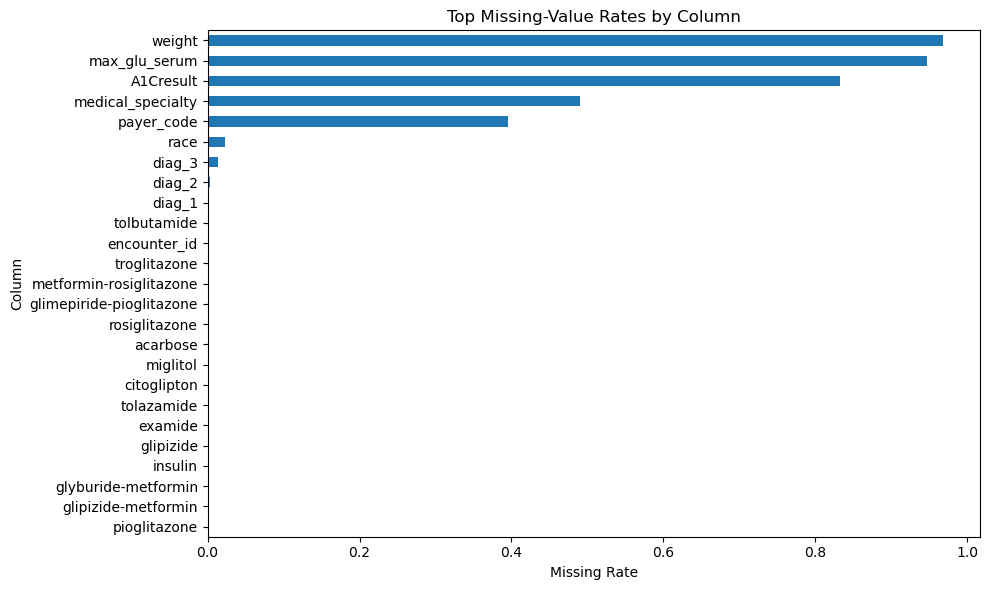

In [181]:
plt.figure(figsize=(10, 6))
missing_rate.head(25).sort_values().plot(kind="barh")
plt.title("Top Missing-Value Rates by Column")
plt.xlabel("Missing Rate")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [182]:
df = df_raw.copy().replace("?", np.nan)

df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print("Binary target counts:")
display(df["readmitted_30"].value_counts())

print("Binary target proportions:")
display(df["readmitted_30"].value_counts(normalize=True).round(4))

Binary target counts:


readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Binary target proportions:


readmitted_30
0    0.8884
1    0.1116
Name: proportion, dtype: float64

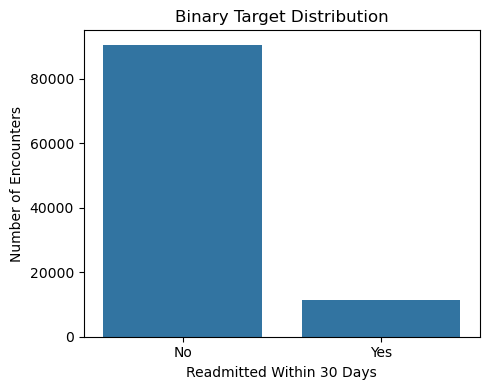

In [183]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="readmitted_30")
plt.title("Binary Target Distribution")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Number of Encounters")
plt.xticks([0, 1], ["No", "Yes"])
plt.tight_layout()
plt.show()

In [184]:
REMOVE_EXPIRED_HOSPICE = True

EXPIRED_HOSPICE_DISPOSITION_IDS = {11, 13, 14, 19, 20, 21}

MEDICATION_COLUMNS = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

In [185]:
def map_icd9_to_group(code):
    if pd.isna(code):
        return "Missing"

    code = str(code).strip()

    if code == "":
        return "Missing"

    if code.startswith("V"):
        return "Supplementary_V"

    if code.startswith("E"):
        return "Supplementary_E"

    try:
        value = float(code)
    except ValueError:
        return "Other"

    if 390 <= value <= 459 or value == 785:
        return "Circulatory"
    elif 460 <= value <= 519 or value == 786:
        return "Respiratory"
    elif 520 <= value <= 579 or value == 787:
        return "Digestive"
    elif 250 <= value < 251:
        return "Diabetes"
    elif 800 <= value <= 999:
        return "Injury"
    elif 710 <= value <= 739:
        return "Musculoskeletal"
    elif 580 <= value <= 629 or value == 788:
        return "Genitourinary"
    elif 140 <= value <= 239:
        return "Neoplasms"
    elif 240 <= value <= 279:
        return "Endocrine_Except_Diabetes"
    elif 680 <= value <= 709 or value == 782:
        return "Skin"
    elif 780 <= value <= 799:
        return "Symptoms"
    else:
        return "Other"

In [186]:
def engineer_features(df_in):
    df = df_in.copy()
    df = df.replace("?", np.nan)

    if "gender" in df.columns:
        df["gender"] = df["gender"].replace({"Unknown/Invalid": np.nan})

    if REMOVE_EXPIRED_HOSPICE and "discharge_disposition_id" in df.columns:
        discharge_numeric = pd.to_numeric(
            df["discharge_disposition_id"],
            errors="coerce"
        )

        before = len(df)

        df = df.loc[
            ~discharge_numeric.isin(EXPIRED_HOSPICE_DISPOSITION_IDS)
        ].copy()

        after = len(df)

        print(f"Removed {before - after} expired/hospice discharge encounters.")

    df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

    for col in ["diag_1", "diag_2", "diag_3"]:
        if col in df.columns:
            df[f"{col}_group"] = df[col].apply(map_icd9_to_group)

    med_cols_present = [
        col for col in MEDICATION_COLUMNS
        if col in df.columns
    ]

    if med_cols_present:
        df["num_med_up"] = (df[med_cols_present] == "Up").sum(axis=1)
        df["num_med_down"] = (df[med_cols_present] == "Down").sum(axis=1)
        df["num_med_steady"] = (df[med_cols_present] == "Steady").sum(axis=1)
        df["num_med_no"] = (df[med_cols_present] == "No").sum(axis=1)

        df["any_med_change_detail"] = (
            (df["num_med_up"] + df["num_med_down"]) > 0
        ).astype(int)
    # --------------------------------------------
    # Healthcare utilization features
    # --------------------------------------------

    if all(col in df.columns for col in ["number_outpatient", "number_emergency", "number_inpatient"]):
        df["total_prior_visits"] = (
            df["number_outpatient"]
            + df["number_emergency"]
            + df["number_inpatient"]
        )

        df["had_prior_outpatient"] = (df["number_outpatient"] > 0).astype(int)
        df["had_prior_emergency"] = (df["number_emergency"] > 0).astype(int)
        df["had_prior_inpatient"] = (df["number_inpatient"] > 0).astype(int)

        df["inpatient_x_emergency"] = (
            df["number_inpatient"] * df["number_emergency"]
        )

    # --------------------------------------------
    # Hospital complexity features
    # --------------------------------------------

    if "time_in_hospital" in df.columns:
        df["long_hospital_stay"] = (df["time_in_hospital"] >= 7).astype(int)

    if "num_medications" in df.columns:
        df["high_medication_count"] = (df["num_medications"] >= 20).astype(int)

    if "num_lab_procedures" in df.columns:
        df["many_lab_procedures"] = (df["num_lab_procedures"] >= 50).astype(int)

    if "number_diagnoses" in df.columns:
        df["many_diagnoses"] = (df["number_diagnoses"] >= 8).astype(int)

    # --------------------------------------------
    # Intensity-per-day features
    # --------------------------------------------

    if all(col in df.columns for col in ["num_medications", "time_in_hospital"]):
        df["medications_per_day"] = (
            df["num_medications"] / (df["time_in_hospital"] + 1)
        )

    if all(col in df.columns for col in ["num_lab_procedures", "time_in_hospital"]):
        df["labs_per_day"] = (
            df["num_lab_procedures"] / (df["time_in_hospital"] + 1)
        )

    if all(col in df.columns for col in ["num_procedures", "time_in_hospital"]):
        df["procedures_per_day"] = (
            df["num_procedures"] / (df["time_in_hospital"] + 1)
        )

    # --------------------------------------------
    # Medication-change intensity
    # --------------------------------------------

    if all(col in df.columns for col in ["num_med_up", "num_med_down"]):
        df["total_med_dose_changes"] = df["num_med_up"] + df["num_med_down"]
        df["multiple_med_changes"] = (df["total_med_dose_changes"] >= 2).astype(int)
    return df

In [187]:
df_model = engineer_features(df_raw)

print("Modeling dataset shape:", df_model.shape)

display(df_model[[
    "readmitted",
    "readmitted_30",
    "diag_1",
    "diag_1_group",
    "diag_2",
    "diag_2_group",
    "diag_3",
    "diag_3_group"
]].head())

Removed 2423 expired/hospice discharge encounters.
Modeling dataset shape: (99343, 73)


,readmitted,readmitted_30,diag_1,diag_1_group,diag_2,diag_2_group,diag_3,diag_3_group
0,NO,0,250.83,Diabetes,NaN,Missing,NaN,Missing
1,>30,0,276,Endocrine_Except_Diabetes,250.01,Diabetes,255,Endocrine_Except_Diabetes
2,NO,0,648,Other,250,Diabetes,V27,Supplementary_V
3,NO,0,8,Other,250.43,Diabetes,403,Circulatory
4,NO,0,197,Neoplasms,157,Neoplasms,250,Diabetes


In [188]:
TARGET = "readmitted_30"
GROUP_COL = "patient_nbr"

DROP_COLUMNS = [
    "readmitted",
    "readmitted_30",
    "encounter_id",
    "patient_nbr"
]

y_all = df_model[TARGET].astype(int)
groups = df_model[GROUP_COL]

gss_1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_val_idx, test_idx = next(
    gss_1.split(df_model, y_all, groups=groups)
)

train_val = df_model.iloc[train_val_idx].copy()
test = df_model.iloc[test_idx].copy()

In [189]:
gss_2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE
)

train_idx, val_idx = next(
    gss_2.split(
        train_val,
        train_val[TARGET],
        groups=train_val[GROUP_COL]
    )
)

train = train_val.iloc[train_idx].copy()
val = train_val.iloc[val_idx].copy()

In [190]:
if FAST_MODE:
    train = train.sample(
        min(len(train), 25000),
        random_state=RANDOM_STATE
    )

    val = val.sample(
        min(len(val), 8000),
        random_state=RANDOM_STATE
    )

    test = test.sample(
        min(len(test), 8000),
        random_state=RANDOM_STATE
    )

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

print("\nTrain positive rate:", train[TARGET].mean())
print("Validation positive rate:", val[TARGET].mean())
print("Test positive rate:", test[TARGET].mean())

Train shape: (59814, 73)
Validation shape: (19727, 73)
Test shape: (19802, 73)

Train positive rate: 0.11445480991072324
Validation positive rate: 0.11415826025244588
Test positive rate: 0.11190788809211191


In [191]:
X_train = train.drop(
    columns=[col for col in DROP_COLUMNS if col in train.columns]
)

y_train = train[TARGET].astype(int)

X_val = val.drop(
    columns=[col for col in DROP_COLUMNS if col in val.columns]
)

y_val = val[TARGET].astype(int)

X_test = test.drop(
    columns=[col for col in DROP_COLUMNS if col in test.columns]
)

y_test = test[TARGET].astype(int)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (59814, 69)
X_val: (19727, 69)
X_test: (19802, 69)


In [192]:
def target_summary(split_name, y):
    return pd.Series({
        "split": split_name,
        "n": len(y),
        "positive_n": int(y.sum()),
        "positive_rate": float(y.mean())
    })

split_summary = pd.DataFrame([
    target_summary("train", y_train),
    target_summary("validation", y_val),
    target_summary("test", y_test)
])

display(split_summary)

,split,n,positive_n,positive_rate
0,train,59814,6846,0.114455
1,validation,19727,2252,0.114158
2,test,19802,2216,0.111908


In [193]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32", "bool"]
).columns.tolist()

categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]

print("Number of numeric features:", len(numeric_features))
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

Number of numeric features: 30
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'num_med_up', 'num_med_down', 'num_med_steady', 'num_med_no', 'any_med_change_detail', 'total_prior_visits', 'had_prior_outpatient', 'had_prior_emergency', 'had_prior_inpatient', 'inpatient_x_emergency', 'long_hospital_stay', 'high_medication_count', 'many_lab_procedures', 'many_diagnoses', 'medications_per_day', 'labs_per_day', 'procedures_per_day', 'total_med_dose_changes', 'multiple_med_changes']

Number of categorical features: 39
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone',

In [194]:
def make_ohe():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )

In [195]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", make_ohe())
])

In [196]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessor created.")

Preprocessor created.


In [197]:
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return (
            scores - scores.min()
        ) / (
            scores.max() - scores.min() + 1e-12
        )

    return model.predict(X)

In [198]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    if (tn + fp) == 0:
        return np.nan

    return tn / (tn + fp)

In [199]:
def evaluate_predictions(y_true, y_score, threshold=0.50):
    y_pred = (y_score >= threshold).astype(int)

    metrics = OrderedDict()

    metrics["threshold"] = threshold
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)
    metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
    metrics["specificity"] = specificity_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    except ValueError:
        metrics["roc_auc"] = np.nan

    try:
        metrics["average_precision"] = average_precision_score(
            y_true,
            y_score
        )
    except ValueError:
        metrics["average_precision"] = np.nan

    return metrics

In [200]:
def find_best_threshold(y_true, y_score, metric="f1", min_precision=None):
    thresholds = np.linspace(0.01, 0.99, 99)

    rows = []

    for threshold in thresholds:
        metrics = evaluate_predictions(
            y_true,
            y_score,
            threshold=threshold
        )

        rows.append(metrics)

    threshold_df = pd.DataFrame(rows)

    if min_precision is not None:
        eligible = threshold_df[
            threshold_df["precision"] >= min_precision
        ]

        if len(eligible) > 0:
            threshold_df = eligible

    best_idx = threshold_df[metric].idxmax()

    best_threshold = float(
        threshold_df.loc[best_idx, "threshold"]
    )

    return best_threshold, threshold_df

In [201]:
def find_threshold_for_recall_with_precision(
    y_true,
    y_score,
    min_precision=0.18
):
    thresholds = np.linspace(0.01, 0.99, 99)

    rows = []

    for threshold in thresholds:
        metrics = evaluate_predictions(
            y_true,
            y_score,
            threshold=threshold
        )

        rows.append(metrics)

    threshold_df = pd.DataFrame(rows)

    eligible = threshold_df[
        threshold_df["precision"] >= min_precision
    ]

    if len(eligible) == 0:
        print("No threshold met the minimum precision requirement.")
        print("Using best F1 threshold instead.")

        best_idx = threshold_df["f1"].idxmax()
    else:
        best_idx = eligible["recall"].idxmax()

    best_threshold = float(
        threshold_df.loc[best_idx, "threshold"]
    )

    return best_threshold, threshold_df

In [202]:
def plot_confusion(y_true, y_score, threshold, title):
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    display = ConfusionMatrixDisplay(
        cm,
        display_labels=["Not <30", "<30"]
    )

    display.plot(values_format="d", cmap="Blues")

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [203]:
def plot_roc_pr_curves(results_dict, split_name="Validation"):
    plt.figure(figsize=(7, 5))

    for model_name, result in results_dict.items():
        fpr, tpr, _ = roc_curve(
            result["y_true"],
            result["y_score"]
        )

        model_auc = roc_auc_score(
            result["y_true"],
            result["y_score"]
        )

        plt.plot(
            fpr,
            tpr,
            label=f"{model_name} AUC={model_auc:.3f}"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Recall")
    plt.title(f"ROC Curves on {split_name} Set")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))

    for model_name, result in results_dict.items():
        precision, recall, _ = precision_recall_curve(
            result["y_true"],
            result["y_score"]
        )

        ap = average_precision_score(
            result["y_true"],
            result["y_score"]
        )

        plt.plot(
            recall,
            precision,
            label=f"{model_name} AP={ap:.3f}"
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curves on {split_name} Set")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [204]:
models = OrderedDict()

In [205]:
models["Dummy prior baseline"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(
        strategy="prior",
        random_state=RANDOM_STATE
    ))
])

In [206]:
models["Logistic Regression balanced"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [207]:
models["Random Forest balanced"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=1000,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [208]:
models["Extra Trees balanced"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", ExtraTreesClassifier(
        n_estimators=1000,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [209]:
models["MLP tabular neural network"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        alpha=1e-5,
        batch_size=512,
        learning_rate_init=5e-4,
        max_iter=400,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])

In [210]:
if RUN_OPTIONAL_XGBOOST:
    try:
        from xgboost import XGBClassifier

        negative_count, positive_count = np.bincount(y_train)
        scale_pos_weight = negative_count / max(positive_count, 1)

        models["XGBoost regularized"] = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", XGBClassifier(
                n_estimators=1200,
                max_depth=3,
                learning_rate=0.02,
                subsample=0.85,
                colsample_bytree=0.85,
                min_child_weight=5,
                gamma=1.0,
                reg_alpha=0.1,
                reg_lambda=5.0,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

        print("Regularized XGBoost model added.")

    except Exception as e:
        print("XGBoost unavailable. Skipping.")
        print(e)

print("Models ready:")
list(models.keys())

Regularized XGBoost model added.
Models ready:


['Dummy prior baseline',
 'Logistic Regression balanced',
 'Random Forest balanced',
 'Extra Trees balanced',
 'MLP tabular neural network',
 'XGBoost regularized']

In [211]:
trained_models = OrderedDict()
val_results = OrderedDict()
val_metric_rows = []
threshold_tables = {}

In [212]:
for model_name, model in models.items():
    print("\n" + "=" * 80)
    print("Training:", model_name)

    fitted_model = clone(model)

    fitted_model.fit(X_train, y_train)

    y_val_score = get_scores(fitted_model, X_val)

    best_threshold, threshold_table = find_threshold_for_recall_with_precision(
        y_val,
        y_val_score,
        min_precision=0.18
    )

    metrics = evaluate_predictions(
        y_val,
        y_val_score,
        threshold=best_threshold
    )

    metrics["model"] = model_name

    trained_models[model_name] = fitted_model

    val_results[model_name] = {
        "y_true": y_val,
        "y_score": y_val_score,
        "threshold": best_threshold
    }

    val_metric_rows.append(metrics)

    threshold_tables[model_name] = threshold_table

    print("Best validation threshold:", round(best_threshold, 3))

    metrics_display = pd.Series(metrics).drop("model")
    metrics_display = pd.to_numeric(metrics_display, errors="coerce")

    display(metrics_display.round(4))


Training: Dummy prior baseline
No threshold met the minimum precision requirement.
Using best F1 threshold instead.
Best validation threshold: 0.01


threshold            0.0100
accuracy             0.1142
balanced_accuracy    0.5000
precision            0.1142
recall               1.0000
specificity          0.0000
f1                   0.2049
roc_auc              0.5000
average_precision    0.1142
dtype: float64


Training: Logistic Regression balanced
Best validation threshold: 0.53


threshold            0.5300
accuracy             0.6938
balanced_accuracy    0.6032
precision            0.1831
recall               0.4858
specificity          0.7206
f1                   0.2659
roc_auc              0.6477
average_precision    0.2006
dtype: float64


Training: Random Forest balanced
Best validation threshold: 0.43


...

threshold            0.4700
accuracy             0.6779
balanced_accuracy    0.6145
precision            0.1844
recall               0.5324
specificity          0.6966
f1                   0.2740
roc_auc              0.6616
average_precision    0.2000
dtype: float64


Training: MLP tabular neural network
Best validation threshold: 0.12


threshold            0.1200
accuracy             0.7039
balanced_accuracy    0.6043
precision            0.1868
recall               0.4751
specificity          0.7334
f1                   0.2681
roc_auc              0.6583
average_precision    0.2140
dtype: float64


Training: XGBoost regularized
Best validation threshold: 0.49


threshold            0.4900
accuracy             0.6355
balanced_accuracy    0.6295
precision            0.1809
recall               0.6217
specificity          0.6373
f1                   0.2803
roc_auc              0.6725
average_precision    0.2214
dtype: float64

In [213]:
val_metrics = (
    pd.DataFrame(val_metric_rows)
    .set_index("model")
    .sort_values("average_precision", ascending=False)
)

display(val_metrics.round(4))

,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,average_precision
model,,,,,,,,,
XGBoost regularized,0.49,0.6355,0.6295,0.1809,0.6217,0.6373,0.2803,0.6725,0.2214
MLP tabular neural network,0.12,0.7039,0.6043,0.1868,0.4751,0.7334,0.2681,0.6583,0.2140
Random Forest balanced,0.43,0.6509,0.6198,0.1801,0.5795,0.6601,0.2748,0.6661,0.2051
Logistic Regression balanced,0.53,0.6938,0.6032,0.1831,0.4858,0.7206,0.2659,0.6477,0.2006
Extra Trees balanced,0.47,0.6779,0.6145,0.1844,0.5324,0.6966,0.2740,0.6616,0.2000
Dummy prior baseline,0.01,0.1142,0.5000,0.1142,1.0000,0.0000,0.2049,0.5000,0.1142


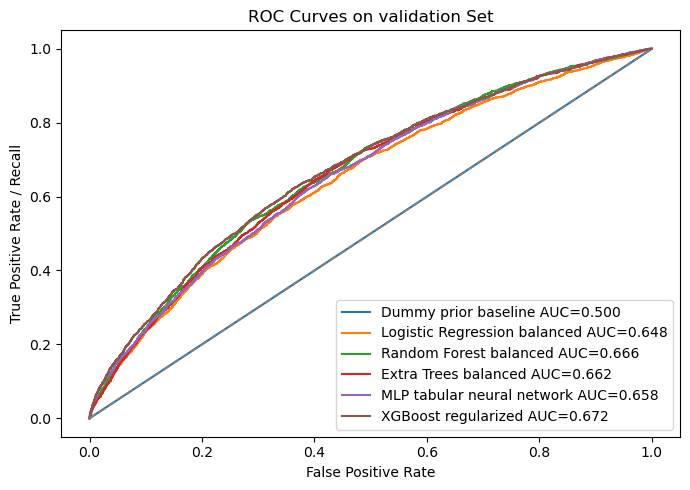

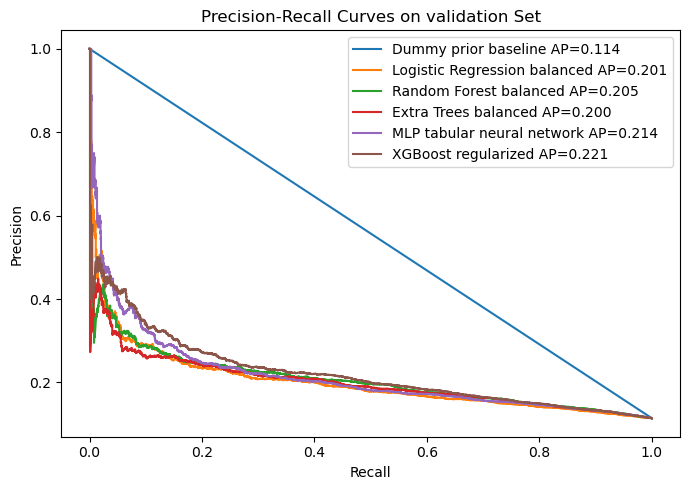

In [214]:
plot_roc_pr_curves(val_results, split_name="validation")

Best validation model by average precision:
XGBoost regularized


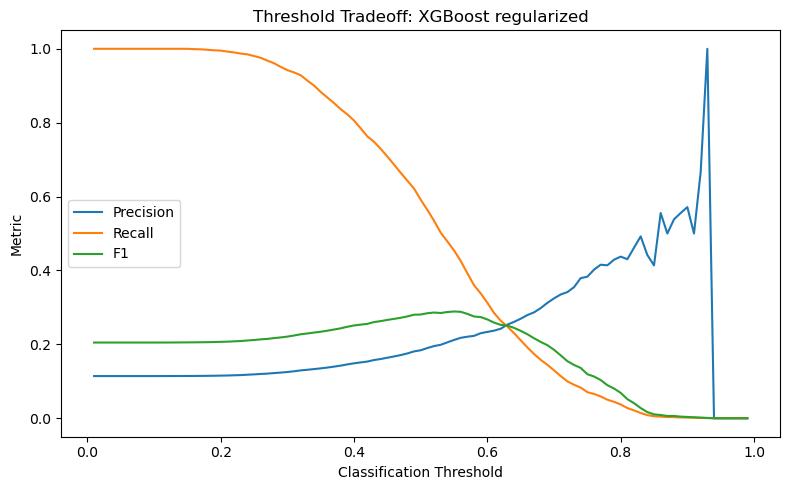

In [215]:
best_val_model_name = val_metrics.index[0]

print("Best validation model by average precision:")
print(best_val_model_name)

threshold_table = threshold_tables[best_val_model_name]

plt.figure(figsize=(8, 5))
plt.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
plt.plot(threshold_table["threshold"], threshold_table["f1"], label="F1")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric")
plt.title(f"Threshold Tradeoff: {best_val_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

In [216]:
selection_metric = "average_precision"

best_model_name = val_metrics.sort_values(
    selection_metric,
    ascending=False
).index[0]

best_model = trained_models[best_model_name]
best_threshold = val_results[best_model_name]["threshold"]

print("Selected model:", best_model_name)
print("Validation-tuned threshold:", best_threshold)

Selected model: XGBoost regularized
Validation-tuned threshold: 0.49


In [217]:
test_results = OrderedDict()
test_metric_rows = []

for model_name, fitted_model in trained_models.items():
    y_test_score = get_scores(fitted_model, X_test)

    threshold = val_results[model_name]["threshold"]

    metrics = evaluate_predictions(
        y_test,
        y_test_score,
        threshold=threshold
    )

    metrics["model"] = model_name

    test_metric_rows.append(metrics)

    test_results[model_name] = {
        "y_true": y_test,
        "y_score": y_test_score,
        "threshold": threshold
    }

test_metrics = (
    pd.DataFrame(test_metric_rows)
    .set_index("model")
    .sort_values(selection_metric, ascending=False)
)

display(test_metrics.round(4))

,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,average_precision
model,,,,,,,,,
XGBoost regularized,0.49,0.6343,0.6259,0.1758,0.6151,0.6368,0.2735,0.6695,0.2230
MLP tabular neural network,0.12,0.7039,0.6089,0.1858,0.4865,0.7313,0.2689,0.6542,0.2110
Random Forest balanced,0.43,0.6477,0.6165,0.1746,0.5763,0.6567,0.2680,0.6610,0.2052
Logistic Regression balanced,0.53,0.6914,0.6056,0.1802,0.4950,0.7161,0.2642,0.6444,0.2015
Extra Trees balanced,0.47,0.6706,0.6079,0.1758,0.5271,0.6887,0.2637,0.6553,0.2006
Dummy prior baseline,0.01,0.1119,0.5000,0.1119,1.0000,0.0000,0.2013,0.5000,0.1119


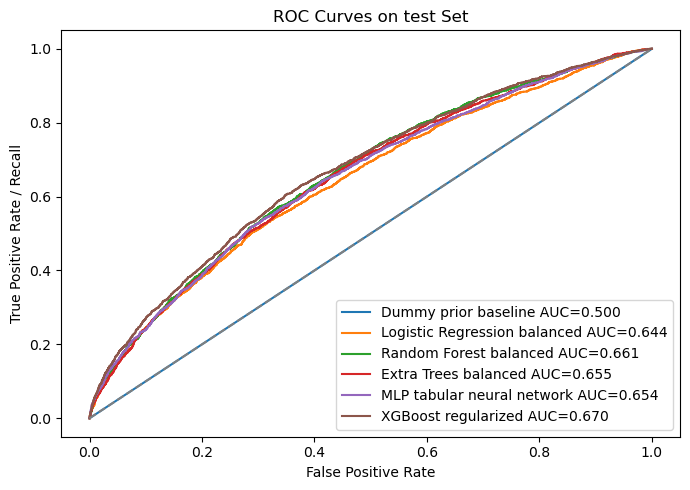

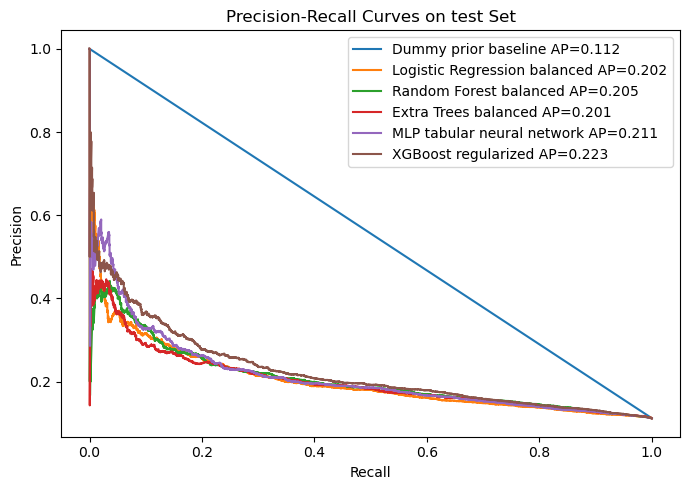

In [218]:
plot_roc_pr_curves(test_results, split_name="test")

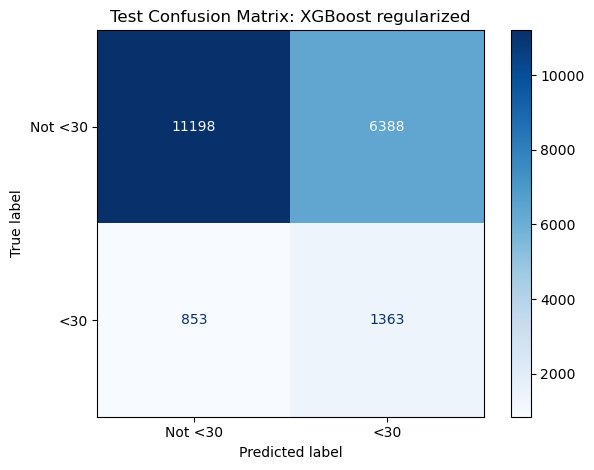

                    precision    recall  f1-score   support

Not readmitted <30     0.9292    0.6368    0.7557     17586
    Readmitted <30     0.1758    0.6151    0.2735      2216

          accuracy                         0.6343     19802
         macro avg     0.5525    0.6259    0.5146     19802
      weighted avg     0.8449    0.6343    0.7017     19802



In [219]:
y_test_score_best = test_results[best_model_name]["y_score"]
y_test_pred_best = (y_test_score_best >= best_threshold).astype(int)

plot_confusion(
    y_test,
    y_test_score_best,
    best_threshold,
    f"Test Confusion Matrix: {best_model_name}"
)

print(
    classification_report(
        y_test,
        y_test_pred_best,
        target_names=["Not readmitted <30", "Readmitted <30"],
        digits=4
    )
)

In [220]:
def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):
    feature_names = []

    feature_names.extend(numeric_features)

    cat_pipeline = preprocessor.named_transformers_["cat"]
    ohe = cat_pipeline.named_steps["onehot"]

    try:
        categorical_names = ohe.get_feature_names_out(categorical_features).tolist()
    except Exception:
        categorical_names = ohe.get_feature_names(categorical_features).tolist()

    feature_names.extend(categorical_names)

    return np.array(feature_names)

In [221]:
logistic_model_names = [
    name for name in trained_models
    if "Logistic Regression" in name
]

if len(logistic_model_names) > 0:
    logistic_name = logistic_model_names[0]
    logistic_model = trained_models[logistic_name]

    feature_names = get_feature_names_from_preprocessor(
        logistic_model.named_steps["preprocess"],
        numeric_features,
        categorical_features
    )

    coefficients = logistic_model.named_steps["model"].coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

    top_positive = coef_df.sort_values(
        "coefficient",
        ascending=False
    ).head(20)

    top_negative = coef_df.sort_values(
        "coefficient",
        ascending=True
    ).head(20)

    print("Top predictors increasing predicted readmission risk:")
    display(top_positive)

    print("Top predictors decreasing predicted readmission risk:")
    display(top_negative)

else:
    print("No logistic regression model was found.")

Top predictors increasing predicted readmission risk:


,feature,coefficient,abs_coefficient
536,diag_2_625,1.570025,1.570025
366,diag_1_V58,1.562650,1.562650
829,diag_3_V64,1.188147,1.188147
229,diag_1_443,1.136626,1.136626
301,diag_1_642,0.977156,0.977156
710,diag_3_444,0.963124,0.963124
438,diag_2_332,0.961650,0.961650
82,medical_specialty_Hematology,0.958655,0.958655
295,diag_1_608,0.930535,0.930535
595,diag_2_V49,0.912918,0.912918


Top predictors decreasing predicted readmission risk:


,feature,coefficient,abs_coefficient
431,diag_2_301,-1.904691,1.904691
701,diag_3_429,-1.782926,1.782926
738,diag_3_537,-1.638838,1.638838
196,diag_1_386,-1.622558,1.622558
571,diag_2_807,-1.565341,1.565341
96,medical_specialty_Otolaryngology,-1.539086,1.539086
514,diag_2_568,-1.457872,1.457872
471,diag_2_429,-1.409605,1.409605
482,diag_2_455,-1.406083,1.406083
719,diag_3_473,-1.393192,1.393192


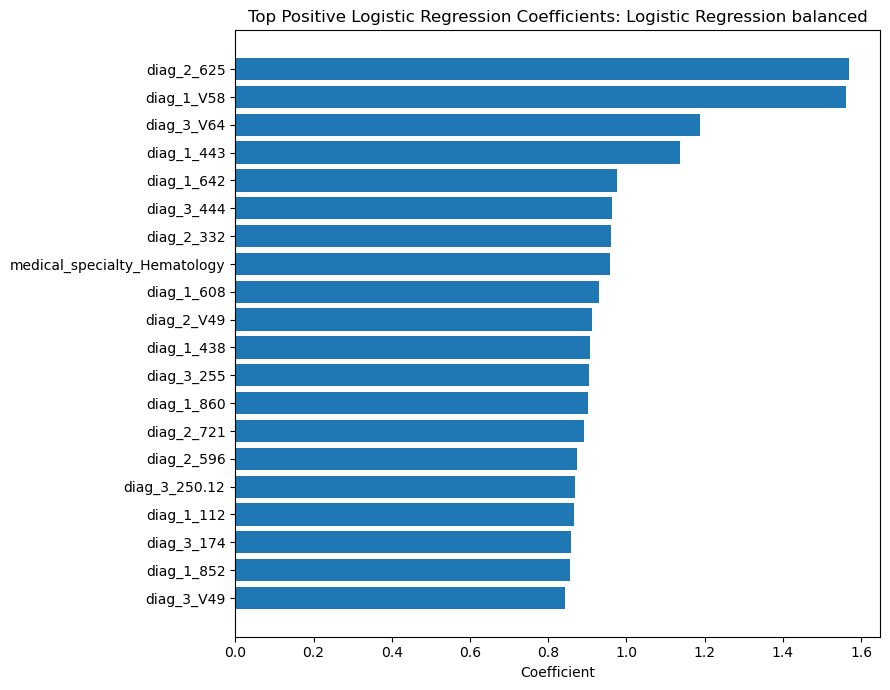

In [222]:
if len(logistic_model_names) > 0:
    plt.figure(figsize=(9, 7))

    plot_df = top_positive.sort_values("coefficient")

    plt.barh(
        plot_df["feature"],
        plot_df["coefficient"]
    )

    plt.title(f"Top Positive Logistic Regression Coefficients: {logistic_name}")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

In [223]:
RUN_PERMUTATION_IMPORTANCE = True
PERMUTATION_SAMPLE_SIZE = 3000 if FAST_MODE else 5000

if RUN_PERMUTATION_IMPORTANCE:
    X_perm = X_val.sample(
        min(len(X_val), PERMUTATION_SAMPLE_SIZE),
        random_state=RANDOM_STATE
    )

    y_perm = y_val.loc[X_perm.index]

    print(f"Running permutation importance on {len(X_perm)} validation rows...")

    permutation_result = permutation_importance(
        best_model,
        X_perm,
        y_perm,
        scoring="average_precision",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    perm_df = pd.DataFrame({
        "feature": X_perm.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std
    })

    perm_df = perm_df.sort_values(
        "importance_mean",
        ascending=False
    )

    display(perm_df.head(25))

else:
    print("Permutation importance skipped.")

Running permutation importance on 5000 validation rows...


,feature,importance_mean,importance_std
15,number_inpatient,0.055001,0.003534
5,discharge_disposition_id,0.030643,0.003251
55,total_prior_visits,0.005755,0.001732
18,diag_3,0.003990,0.000384
8,payer_code,0.003280,0.001697
14,number_emergency,0.003173,0.000359
17,diag_2,0.001746,0.001047
59,inpatient_x_emergency,0.001586,0.000175
52,num_med_steady,0.001517,0.000453
9,medical_specialty,0.001267,0.000847


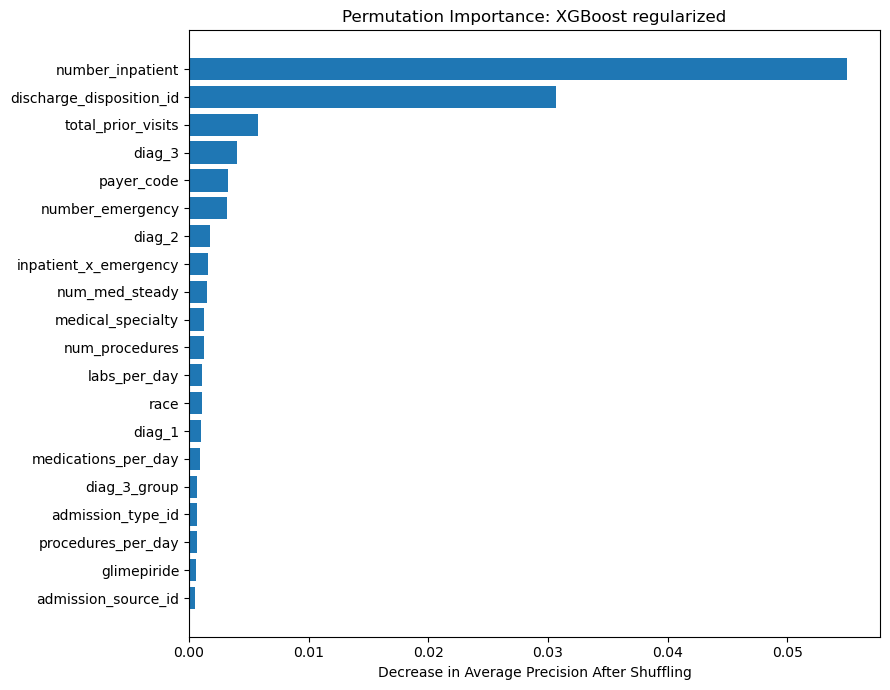

In [224]:
if RUN_PERMUTATION_IMPORTANCE:
    plt.figure(figsize=(9, 7))

    plot_df = perm_df.head(20).sort_values("importance_mean")

    plt.barh(
        plot_df["feature"],
        plot_df["importance_mean"]
    )

    plt.xlabel("Decrease in Average Precision After Shuffling")
    plt.title(f"Permutation Importance: {best_model_name}")
    plt.tight_layout()
    plt.show()